 # Getting Started with scHopfield



 scHopfield models gene regulatory networks (GRNs) as continuous Hopfield

 networks, where gene expression dynamics follow:



 $$\frac{dx}{dt} = W \cdot \sigma(x) - \gamma \cdot x + I$$



 - **W**: Interaction matrix encoding gene-gene regulatory relationships

 - **σ(x)**: Sigmoid activation function fitted to expression data

 - **γ**: Degradation rates (mRNA decay)

 - **I**: Bias vector representing external inputs / basal expression



 This notebook walks through the full setup: data loading, sigmoid fitting,

 network inference (with and without a scaffold), and saving/loading the model.

 ## 1.1 Setup & Imports

In [11]:
import numpy as np
import scanpy as sc
import scHopfield as sch
import matplotlib.pyplot as plt

# Analysis parameters (update for your dataset)
DATA_PATH = './scratch/Data/'
DATASET_FILE = 'hematopoiesis.h5ad'

CLUSTER_KEY = 'cell_type'
VELOCITY_KEY = 'velocity_alpha_minus_gamma_s'
SPLICED_KEY  = 'M_t'
DEGRADATION_KEY = 'gamma'
DYNAMIC_GENES_KEY = 'use_for_dynamics'

CELL_TYPE_ORDER = ['Meg', 'Ery', 'MEP-like', 'HSC', 'GMP-like', 'Mon', 'Bas', 'Neu']

# Network inference hyper-parameters
N_EPOCHS              = 1000
BATCH_SIZE            = 128
W_THRESHOLD           = 1e-12
SCAFFOLD_REGULARIZATION = 1e-2
DEVICE = 'cuda'   # or 'cpu'


 ## 1.2 Data Loading

In [12]:
print("Loading data...")
adata = sc.read_h5ad(DATA_PATH + DATASET_FILE)
print(f"  Loaded: {adata.n_obs} cells × {adata.n_vars} genes")
print(adata)


Loading data...
  Loaded: 1947 cells × 1956 genes
AnnData object with n_obs × n_vars = 1947 × 1956
    obs: 'batch', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'new_Size_Factor', 'initial_new_cell_size', 'total_Size_Factor', 'initial_total_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr', 'cell_cycle_phase', 'leiden', 'control_point_pca', 'inlier_prob_pca', 'obs_vf_angle_pca', 'pca_ddhodge_div', 'pca_ddhodge_potential', 'acceleration_pca', 'curvature_pca', 'n_counts', 'mt_frac', 'jacobian_det_pca', 'manual_selection', 'divergence_pca', 'curv_leiden', 'curv_louvain', 'SPI1->GATA1_jacobian', 'jacobian', 'umap_ori_leiden', 'umap_ori_louvain', 'umap_ddhodge_div', 'umap_ddhodge_potential', 'curl_umap', 'divergence_umap', 'acceleration_umap', 'control_point_umap_ori', 'inlier_prob_umap_ori', 'obs_vf_angle_umap_ori', 'curvature_umap_ori'
    var: 'gene_

 ## 1.3 Preprocessing



 Remove genes with NaN velocities by subsetting adata, then identify the

 dynamic genes that will be passed to the model.

In [13]:
# Remove genes that have any NaN velocity entry (hematopoiesis dataset)
print("Removing genes with NaN velocities...")
velocity_layer = adata.layers[VELOCITY_KEY]
if hasattr(velocity_layer, 'toarray'):
    velocity_layer = velocity_layer.toarray()
bad_gene_idx = np.unique(np.where(np.isnan(velocity_layer))[1])
keep_mask = np.ones(adata.n_vars, dtype=bool)
keep_mask[bad_gene_idx] = False
adata = adata[:, keep_mask].copy()
print(f"  After filtering: {adata.n_obs} cells × {adata.n_vars} genes")

# Boolean mask of dynamic genes used for modelling
genes_to_use = adata.var[DYNAMIC_GENES_KEY].values
n_genes = genes_to_use.sum()
print(f"  Dynamic genes for modelling: {n_genes}")


Removing genes with NaN velocities...
  After filtering: 1947 cells × 1728 genes
  Dynamic genes for modelling: 1728


 ## 1.4 Sigmoid Fitting



 Fit a sigmoid function σ(x) = 1 / (1 + exp(-k*(x - x0))) to each gene's

 expression distribution.  The fitted parameters are stored in `adata.var`.

In [14]:
sch.pp.fit_all_sigmoids(
    adata,
    spliced_key=SPLICED_KEY,
    genes=adata.var[DYNAMIC_GENES_KEY].values
)

sch.pp.compute_sigmoid(adata, spliced_key=SPLICED_KEY, copy=False)

print("Sigmoid fitting complete.")
print(adata)


/home/bernaljp/packages/scHopfield/scHopfield/_utils/math.py:93: RuntimeWarning: divide by zero encountered in divide
  ty = np.log(y / (1 - y))
/home/bernaljp/packages/scHopfield/scHopfield/_utils/math.py:93: RuntimeWarning: divide by zero encountered in log
  ty = np.log(y / (1 - y))


Sigmoid fitting complete.
AnnData object with n_obs × n_vars = 1947 × 1728
    obs: 'batch', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'new_Size_Factor', 'initial_new_cell_size', 'total_Size_Factor', 'initial_total_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr', 'cell_cycle_phase', 'leiden', 'control_point_pca', 'inlier_prob_pca', 'obs_vf_angle_pca', 'pca_ddhodge_div', 'pca_ddhodge_potential', 'acceleration_pca', 'curvature_pca', 'n_counts', 'mt_frac', 'jacobian_det_pca', 'manual_selection', 'divergence_pca', 'curv_leiden', 'curv_louvain', 'SPI1->GATA1_jacobian', 'jacobian', 'umap_ori_leiden', 'umap_ori_louvain', 'umap_ddhodge_div', 'umap_ddhodge_potential', 'curl_umap', 'divergence_umap', 'acceleration_umap', 'control_point_umap_ori', 'inlier_prob_umap_ori', 'obs_vf_angle_umap_ori', 'curvature_umap_ori'
    var: 'gene_name', 'gene_id', 'nCell

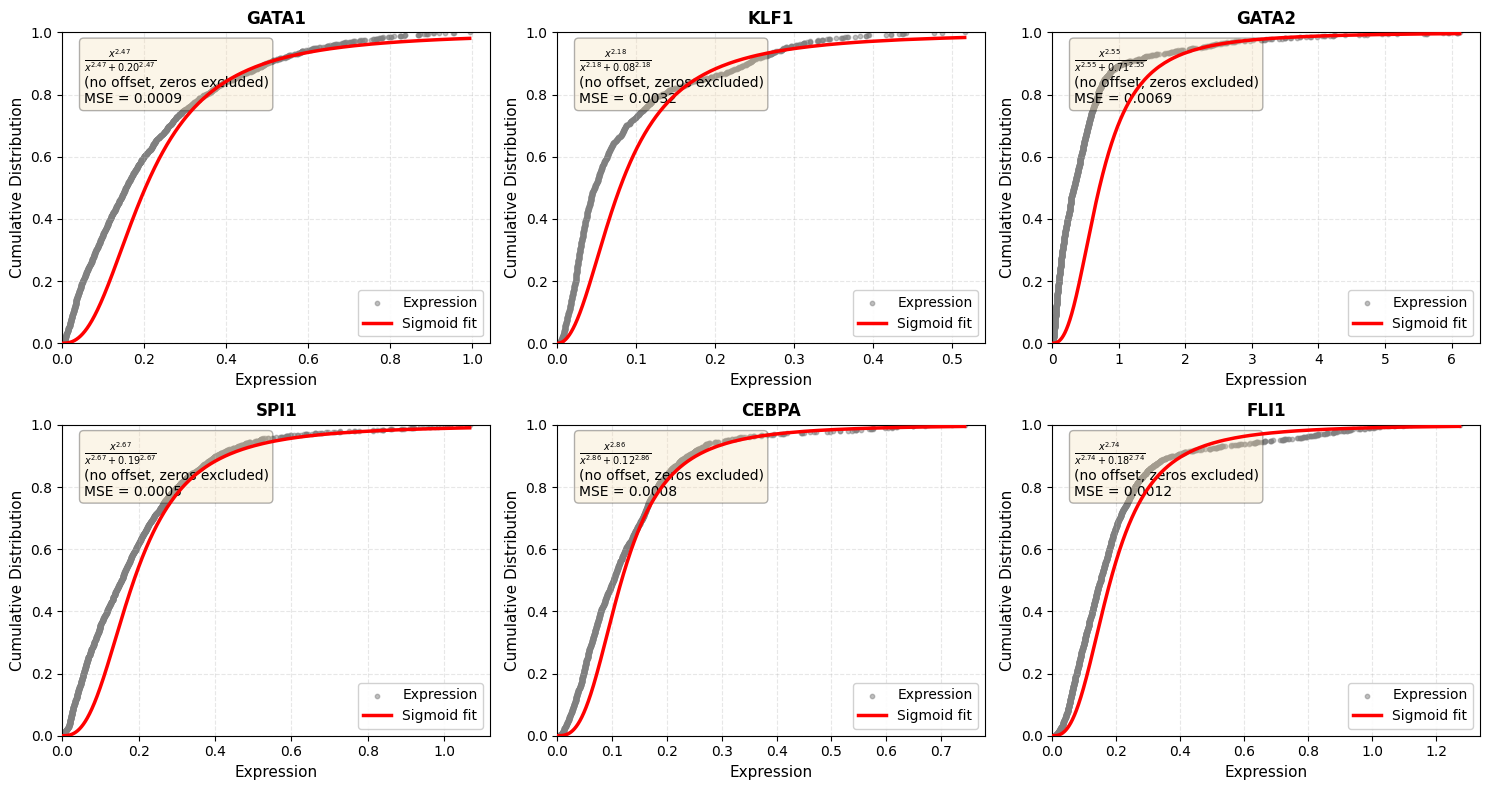

In [15]:
# Visualize sigmoid fits for key genes
genes_to_plot = ['Gata1', 'Klf1', 'Gata2', 'Spi1', 'Cebpa', 'FLI1']
genes_to_plot = [g.upper() for g in genes_to_plot if g.upper() in adata.var_names]

if genes_to_plot:
    n_cols = min(3, len(genes_to_plot))
    n_rows = (len(genes_to_plot) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=[5*n_cols, 4*n_rows])
    axes = np.atleast_2d(axes).flatten()

    for i, gene in enumerate(genes_to_plot):
        sch.pl.plot_sigmoid_fit(adata, gene=gene, ax=axes[i],
                                spliced_key='M_t', show_zeros=False)

    # Hide empty axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

 ## 1.5 Network Inference (no scaffold)



 Learn the interaction matrix **W** for each cell cluster by minimizing the

 velocity reconstruction error.

In [16]:
sch.inf.fit_interactions(
    adata,
    cluster_key=CLUSTER_KEY,
    spliced_key=SPLICED_KEY,
    velocity_key=VELOCITY_KEY,
    degradation_key=DEGRADATION_KEY,
    w_threshold=W_THRESHOLD,
    infer_I=True,
    refit_gamma=False,
    n_epochs=N_EPOCHS,
    criterion='MSE',
    batch_size=BATCH_SIZE,
    use_scheduler=True,
    get_plots=False,
    device=DEVICE,
)

print("Network inference complete (no scaffold).")


Inferring interaction matrix W and bias vector I for cluster Mon
Inferring interaction matrix W and bias vector I for cluster Meg
Inferring interaction matrix W and bias vector I for cluster MEP-like
Inferring interaction matrix W and bias vector I for cluster Ery
Inferring interaction matrix W and bias vector I for cluster Bas
Inferring interaction matrix W and bias vector I for cluster GMP-like
Inferring interaction matrix W and bias vector I for cluster HSC
Inferring interaction matrix W and bias vector I for cluster Neu
Inferring interaction matrix W and bias vector I for cluster all
Network inference complete (no scaffold).


 ## 1.6 Scaffold-Constrained Inference



 Load a prior gene regulatory network (GRN) from CellOracle's mouse scATAC-seq

 atlas and use it as a scaffold to regularise the learned **W** matrix.

In [17]:
import celloracle as co
import pandas as pd

print("Loading CellOracle scaffold...")
base_GRN = co.data.load_mouse_scATAC_atlas_base_GRN()
base_GRN.drop(['peak_id'], axis=1, inplace=True)

# Build scaffold matrix (genes × genes; 1 = edge allowed by prior)
scaffold = pd.DataFrame(
    0,
    index=adata.var.index[genes_to_use],
    columns=adata.var.index[genes_to_use]
)

tfs = list(set(base_GRN.columns.str.lower()) & set(scaffold.index.str.lower()))
target_genes = list(
    set(base_GRN['gene_short_name'].str.lower().values) & set(scaffold.columns.str.lower())
)

index_map = {gene.lower(): gene for gene in scaffold.index}
col_map   = {gene.lower(): gene for gene in scaffold.columns}

for tf in tfs:
    tf_original = index_map[tf]
    tf_col = [c for c in base_GRN.columns if c.lower() == tf][0]
    for target in base_GRN[base_GRN[tf_col] == 1]['gene_short_name']:
        if target.lower() in target_genes:
            scaffold.loc[tf_original, col_map[target.lower()]] = 1

print(f"  Scaffold: {scaffold.sum().sum()} potential connections")
print(f"  TFs: {len(tfs)}, Target genes: {len(target_genes)}")


which: no R in (/opt/slurm/puppet/bin:/opt/slurm/cluster/ibex/install-v2/RedHat-9/bin:/opt/slurm/scripts/bin:/usr/lpp/mmfs/bin:/home/bernaljp/miniconda3/envs/SCH/bin:/opt/slurm/puppet/bin:/opt/slurm/cluster/ibex/install-v2/RedHat-9/bin:/opt/slurm/scripts/bin:/usr/lpp/mmfs/bin:/home/bernaljp/miniconda3/condabin:/opt/slurm/puppet/bin:/usr/share/Modules/bin:/opt/slurm/cluster/ibex/install-v2/RedHat-9/bin:/opt/slurm/scripts/bin:/usr/lpp/mmfs/bin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/opt/slurm/scripts/bin:/opt/puppetlabs/bin:/home/bernaljp/.local/bin:/home/bernaljp/bin:/opt/slurm/scripts/bin:/home/bernaljp/.local/bin:/home/bernaljp/bin:/opt/slurm/scripts/bin:/home/bernaljp/.local/bin:/home/bernaljp/bin)


Loading CellOracle scaffold...
  Scaffold: 41693 potential connections
  TFs: 73, Target genes: 1148


In [18]:
sch.inf.fit_interactions(
    adata,
    cluster_key=CLUSTER_KEY,
    spliced_key=SPLICED_KEY,
    velocity_key=VELOCITY_KEY,
    degradation_key=DEGRADATION_KEY,
    w_threshold=W_THRESHOLD,
    w_scaffold=scaffold.values.T,
    scaffold_regularization=SCAFFOLD_REGULARIZATION,
    only_TFs=True,
    infer_I=True,
    refit_gamma=False,
    n_epochs=N_EPOCHS,
    criterion='MSE',
    batch_size=BATCH_SIZE,
    use_scheduler=True,
    get_plots=False,
    device=DEVICE,
)

print("Scaffold-constrained network inference complete.")


Inferring interaction matrix W and bias vector I for cluster Mon


/home/bernaljp/packages/scHopfield/scHopfield/inference/optimizer.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('mask', torch.tensor(mask, dtype=torch.float32, device=device))
Training Epochs:   1%|▏         | 14/1000 [00:00<00:16, 59.28it/s]

[Epoch 1/1000] Total Loss: 64.135234, Reconstruction Loss: 0.506700, LR: 1.00e-01, Batch size: 128


Training Epochs:  12%|█▏        | 118/1000 [00:01<00:07, 120.50it/s]

[Epoch 101/1000] Total Loss: 10.224924, Reconstruction Loss: 0.008538, LR: 4.00e-02, Batch size: 128


...

[Epoch 801/1000] Total Loss: 0.010392, Reconstruction Loss: 0.000840, LR: 6.55e-05, Batch size: 128


Training Epochs:  91%|█████████ | 906/1000 [00:36<00:03, 24.93it/s]

[Epoch 901/1000] Total Loss: 0.004732, Reconstruction Loss: 0.000837, LR: 2.62e-05, Batch size: 128


Training Epochs: 100%|██████████| 1000/1000 [00:40<00:00, 24.98it/s]

[Epoch 1000/1000] Total Loss: 0.003121, Reconstruction Loss: 0.000838, LR: 1.05e-05, Batch size: 128
Scaffold-constrained network inference complete.


 ## 1.7 Save / Load Model



 Models can be serialised to an HDF5 file for later use.  This is especially

 useful for large datasets where re-inference is expensive.

In [19]:
# Save the fitted model
MODEL_FILE = 'model.h5sch'
sch.tl.save_model(adata, MODEL_FILE)
print(f"Model saved to '{MODEL_FILE}'")


Model saved to 'model.h5sch'


In [25]:
# Load the model back into a fresh AnnData object.
# If adata_loaded has more genes than the saved model (e.g. the full dataset
# before NaN filtering), load_model subsets it in-place to the model gene set.
adata_loaded = sc.read_h5ad(DATA_PATH + DATASET_FILE)
sch.tl.load_model(adata_loaded, MODEL_FILE)
print("Model loaded successfully.")
print(adata_loaded)


Model loaded from 'model.h5sch'  |  clusters=['Bas', 'Ery', 'GMP-like', 'HSC', 'MEP-like', 'Meg', 'Mon', 'Neu', 'all']  |  genes=1728
Model loaded successfully.
AnnData object with n_obs × n_vars = 1947 × 1956
    obs: 'batch', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'new_Size_Factor', 'initial_new_cell_size', 'total_Size_Factor', 'initial_total_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr', 'cell_cycle_phase', 'leiden', 'control_point_pca', 'inlier_prob_pca', 'obs_vf_angle_pca', 'pca_ddhodge_div', 'pca_ddhodge_potential', 'acceleration_pca', 'curvature_pca', 'n_counts', 'mt_frac', 'jacobian_det_pca', 'manual_selection', 'divergence_pca', 'curv_leiden', 'curv_louvain', 'SPI1->GATA1_jacobian', 'jacobian', 'umap_ori_leiden', 'umap_ori_louvain', 'umap_ddhodge_div', 'umap_ddhodge_potential', 'curl_umap', 'divergence_umap', 'acceleration_umap', 

In [29]:
adata_loaded.varp['W_Bas']

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [28]:
adata.varp['W_Bas']

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)